In [1]:
import numpy as np
import time
import sys
import math

import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

import bluequbit

import qiskit.qasm2

In [2]:
q = qiskit.qasm2.load("P5_granite_summit.qasm")

In [3]:
len(q.data)

5764

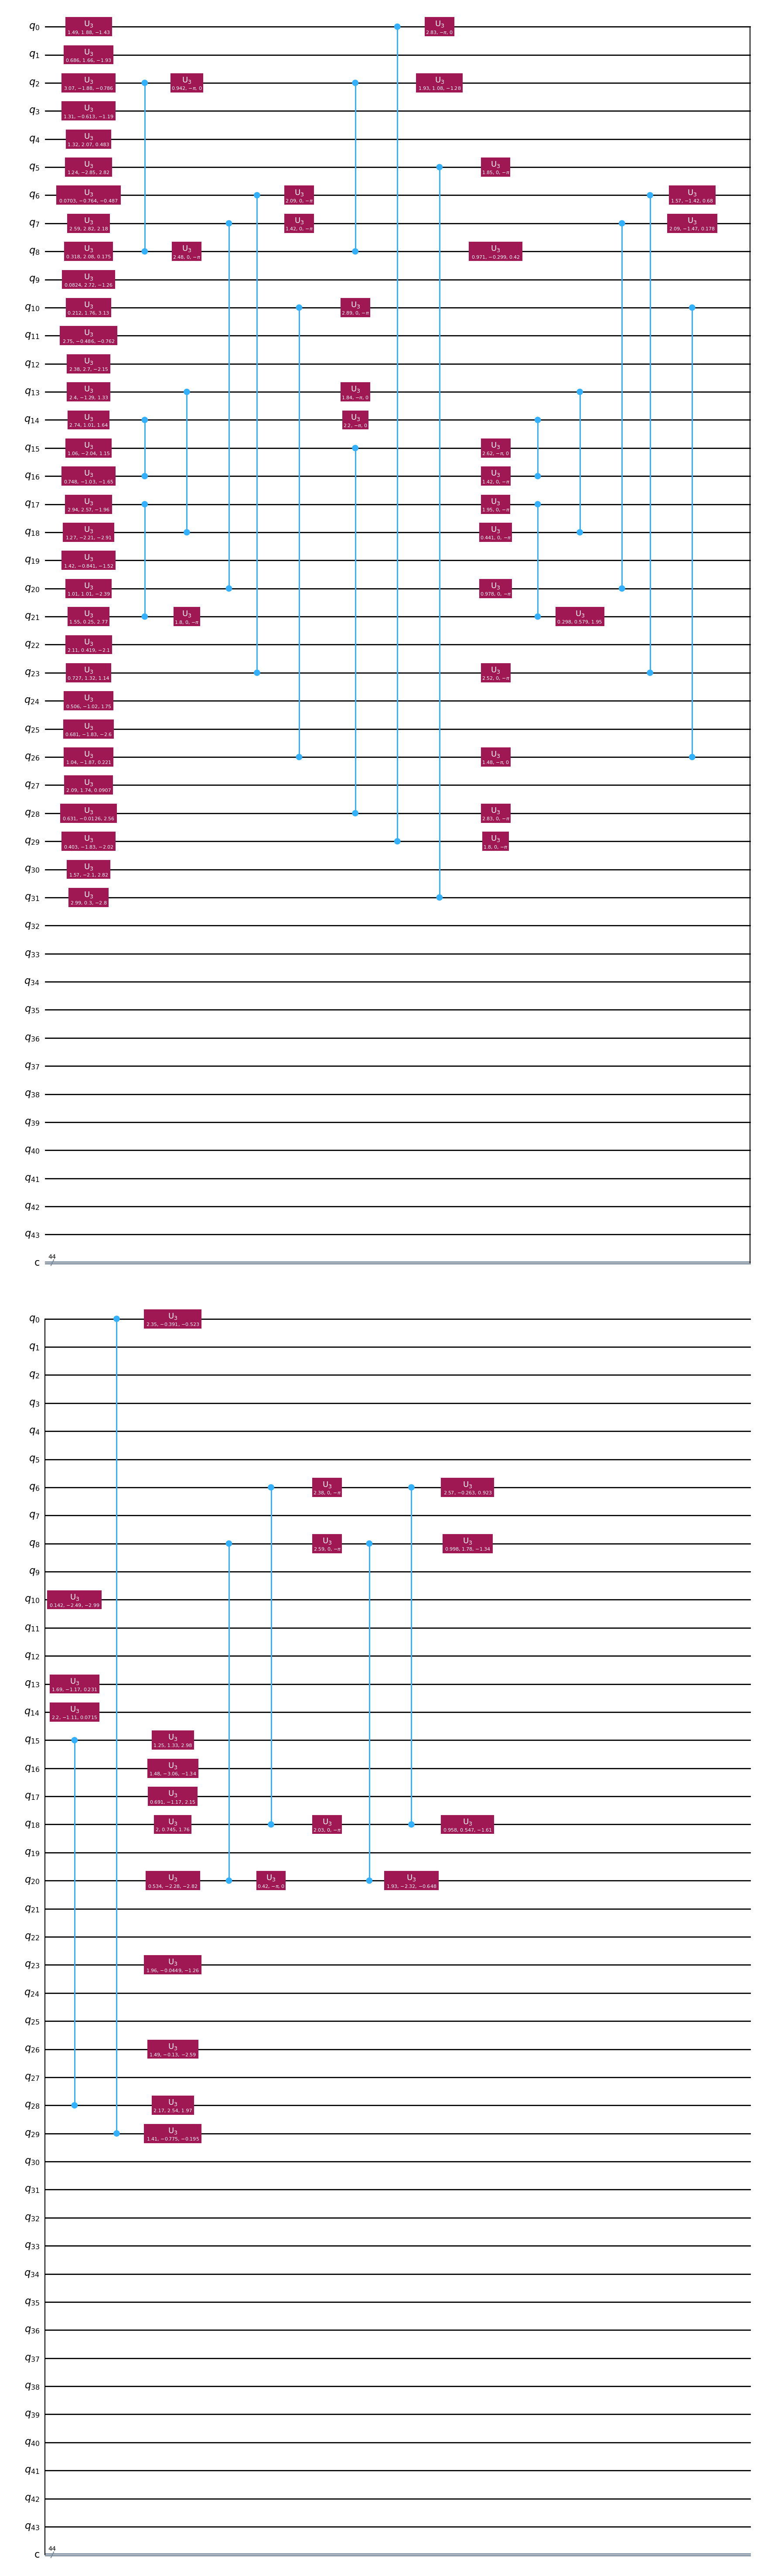

In [4]:
cut_start = 0
cut_number =100

qc_cut = QuantumCircuit(44,44)
for q_i in range(cut_start, cut_start + cut_number):
    qc_cut.append(q.data[q_i], qc_cut.qubits, qc_cut.clbits)

qc_cut.draw('mpl')

In [8]:
bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
result = bq.run(q, device="quantum", options=options, shots=100) # should take ~30seconds

[BQ-PYTHON-SDK][WARNING] - Beta version 0.12.0b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: fCwspJ1reFJWVL1t, device: quantum, run status: PENDING, created on: 2025-04-13 00:49:08 UTC, estimated runtime: 1 ms, estimated cost: $0.39, num qubits: 44


In [9]:
counts = result.get_counts()

In [10]:
counts

{'00011101010111101010011101001110100101001001': 1,
 '00011111011101001101010110011111010110110011': 1,
 '00100001100100110111011001011010100001001011': 1,
 '00100100100011111000110111101101111010011000': 1,
 '00100101110011011111011111100010111100101111': 1,
 '00100110001001000111011100100010100000011001': 1,
 '00100111010100101011010010110101111111100110': 1,
 '00101101010001101111000111010011011111111010': 1,
 '00101110001010110110100001010001001111110011': 1,
 '00110000100011010001100001111101100111010101': 1,
 '00110010110000000101000000010101101111000111': 1,
 '00110110110101110110111100100101110111000010': 1,
 '01000000100001010110111000101011101111111010': 1,
 '01000010100010111101100110110101111110100100': 1,
 '01000101110101110111000010001010111011000110': 1,
 '01000111001101100110000110100101111111001010': 1,
 '01001011000000111111100101011001100111101001': 1,
 '01010110101001111110100001111100100110101101': 1,
 '01010110110001111110100010111000101111011011': 1,
 '0101110011

In [13]:
def check_how_many_cz(qc, qbit_num_1):
    qc_len = len(qc.data)
    gate_num_list = []
    for i in range(qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if the gate involves both the qubits we want to check
        if qubits_number > 1:
            if (q_list[0] == qbit_num_1) or (q_list[1] == qbit_num_1):
                gate_num_list.append(i)
    return gate_num_list

In [15]:
for i in range(44):
    print(len(check_how_many_cz(q, i)))

86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86
86


In [16]:
#the function finds the last gate using qubit qbit_num in circuit qc
def last_gate(qc, qbit_num):
    qubit_last_gate = -1
    qc_len = len(qc.data)
    for i in range(qc_len - 1, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        found = 0
        for i_q in range(qubits_number):
            if cur_gate[1][i_q]._index == qbit_num:
                qubit_last_gate = i
                found = 1
        if found == 1:
            break
    return qubit_last_gate

In [17]:
def light_cone(qc, qbit_num):
    start_point = last_gate(qc, qbit_num)
    qc_len = len(qc.data)
    cone_list = []
    cone_list.append(qbit_num)
    for i in range(start_point, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if qubits particiapating in the gate are in the list of the light cone or not
        if qubits_number > 1:
            if (q_list[0] in cone_list) and (q_list[1] not in cone_list):
                cone_list.append(q_list[1])
            if (q_list[1] in cone_list) and (q_list[0] not in cone_list):
                cone_list.append(q_list[0])
    return cone_list, len(cone_list)

In [19]:
for i in range(44):
    ff,aa = light_cone(q, i)
    print(aa)

44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44


In [12]:
bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
result = bq.run(q, device='cpu', shots = 1000)

BQ-PYTHON-SDK - WARNING - Beta version 0.8.3b1 of BlueQubit Python SDK is being used.
BQ-PYTHON-SDK - INFO - There is a newer version of BlueQubit Python SDK available on PyPI. We recommend upgrading. Run 'pip install --upgrade bluequbit' to upgrade from your version 0.8.3b1 to 0.12.0b1.
BQ-PYTHON-SDK - INFO - Submitted: Job ID: D5xp5lqYoJ2qU7x3, device: cpu, run status: COMPLETED, created on: 2025-04-12 16:04:53 UTC, cost: $0.00, run time: 6 ms, queue time: 102 ms, num qubits: 4


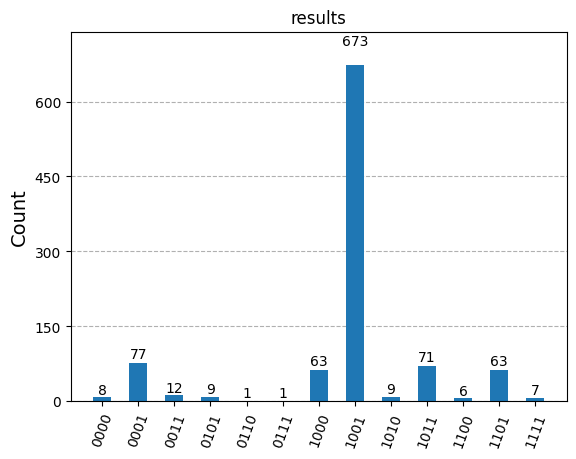

In [13]:
#Getting the counts and hystogram (take long time!)
from qiskit.visualization import plot_histogram
counts = result.get_counts()
plot_histogram(counts, title = 'results')

In [ ]:
#Getting the most probable bit string
for dic in counts:
    if counts[dic] > 50:
        ans = dic
print(ans)
print(counts[ans])

In [24]:
#the function finds the last gate using qubit qbit_num in circuit qc
def last_gate_m(qc, qbit_num, max_gate):
    qubit_last_gate = -1
    qc_len = len(qc.data)
    for i in range(max_gate - 1, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        found = 0
        for i_q in range(qubits_number):
            if cur_gate[1][i_q]._index == qbit_num:
                qubit_last_gate = i
                found = 1
        if found == 1:
            break
    return qubit_last_gate

In [42]:
def light_cone(qc, qbit_num, max_gate):
    start_point = last_gate_m(qc, qbit_num, max_gate)
    qc_len = len(qc.data)
    cone_list = []
    cone_list.append(qbit_num)
    cz_num = 0
    for i in range(start_point, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if qubits particiapating in the gate are in the list of the light cone or not
        if qubits_number > 1:
            if (q_list[0] in cone_list) and (q_list[1] not in cone_list):
                cone_list.append(q_list[1])
                cz_num = cz_num + 1
            if (q_list[1] in cone_list) and (q_list[0] not in cone_list):
                cone_list.append(q_list[0])
                cz_num = cz_num + 1
            if (q_list[1] in cone_list) and (q_list[0] in cone_list):
                cz_num = cz_num + 1
    return cone_list, len(cone_list), start_point, cz_num

In [43]:
for i in range(44):
    a,b,b,d = light_cone(q, i, 5720)
    print(d)
    

1749
1743
1749
1735
1749
1747
1749
1745
1753
1745
1737
1745
1749
1751
1741
1749
1741
1737
1747
1749
1749
1743
1747
1747
1741
1739
1741
1741
1737
1749
1749
1751
1749
1747
1747
1737
1753
1741
1735
1741
1749
1741
1745
1739


In [26]:
def get_closed_circuit_2(qc, q_list, max_gate):
    qc_len = len(qc.data)
    q_list_len = len(q_list)
    qc_re = QuantumCircuit(q_list_len)
    for i in range(max_gate + 1):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'u3':
            cur_angle_1 = cur_gate[0].params[0]
            cur_angle_2 = cur_gate[0].params[1]
            cur_angle_3 = cur_gate[0].params[2]
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.U3Gate(cur_angle_1, cur_angle_2,cur_angle_3)
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'cz':
            curr_q_1 = cur_gate[1][0]._index
            curr_q_2 = cur_gate[1][1]._index
            if (curr_q_1 in q_list) and (curr_q_2 in q_list):
                new_ind_1 = q_list.index(curr_q_1)
                new_ind_2 = q_list.index(curr_q_2)
                gate = qiskit.circuit.library.CZGate()
                qc_re.append(gate, [new_ind_1, new_ind_2])
    qc_re.measure_all()
    return qc_re

In [30]:
q_list, q_list_len, max_gate = light_cone(q, 1, 5720)
qq = get_closed_circuit_2(q, q_list, max_gate)
print(len(qq))

5446


In [31]:
qq.draw('mpl')

ValueError: Image size of 2252x346099 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 2252.61x346100 with 1 Axes>